# Elo + Conference Tournament Games

**Question this notebook answers:** does extending the Elo rating to include each team's
conference tournament games (the smaller, conference-specific tournaments held after the regular
season but before the NCAA tournament) improve on the current best model (gender-split + Elo,
0.1687 average Brier from notebook 11)?

**The gap this addresses:** notebook 11's Elo rating was computed from regular-season games only,
which means it stops updating the moment the regular season ends. In reality, most tournament
teams play 1-4 more games after that — their conference tournament — before the NCAA tournament
starts. Those are recent, high-leverage games (they determine conference champions and
auto-bids), and using them isn't leakage: they're fully complete and known before any NCAA
tournament prediction gets made, exactly like regular-season games are.

**One wrinkle:** the conference tournament file doesn't include final scores or game location —
only who won and who lost. That means the margin-of-victory adjustment used for regular-season
games (bigger wins move the rating more) can't be computed for these games, so they get a neutral,
average-sized adjustment instead, and are treated as played at a neutral site (a reasonable
assumption, since conference tournaments are held at a predetermined neutral venue, not either
team's home court).

**Method:** build one combined game log per gender — regular-season games (with full detail) plus
conference-tournament games (win/loss only) — and compute Elo the same way as notebook 11, just
with more games feeding into it. Both the original (regular-season-only) and extended
(regular-season + conference-tournament) Elo ratings are computed side by side in this notebook,
so they can be compared directly rather than assuming the extension helps.

## 1. Load data

Same six files as notebook 11, plus the two conference tournament files, new to this notebook.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
plt.rcParams["figure.dpi"] = 110

DATA_DIR = Path("../data")

m_tourney = pd.read_csv(DATA_DIR / "MNCAATourneyCompactResults.csv")
w_tourney = pd.read_csv(DATA_DIR / "WNCAATourneyCompactResults.csv")
m_seeds = pd.read_csv(DATA_DIR / "MNCAATourneySeeds.csv")
w_seeds = pd.read_csv(DATA_DIR / "WNCAATourneySeeds.csv")
m_reg = pd.read_csv(DATA_DIR / "MRegularSeasonCompactResults.csv")
w_reg = pd.read_csv(DATA_DIR / "WRegularSeasonCompactResults.csv")
m_conf = pd.read_csv(DATA_DIR / "MConferenceTourneyGames.csv")
w_conf = pd.read_csv(DATA_DIR / "WConferenceTourneyGames.csv")

print(f"men's regular season games: {len(m_reg):,}, men's conference tourney games: {len(m_conf):,}")
print(f"women's regular season games: {len(w_reg):,}, women's conference tourney games: {len(w_conf):,}")
print(f"conference tourney file columns: {list(m_conf.columns)}")


men's regular season games: 198,577, men's conference tourney games: 7,093
women's regular season games: 142,507, women's conference tourney games: 6,777
conference tourney file columns: ['Season', 'ConfAbbrev', 'DayNum', 'WTeamID', 'LTeamID']


## 2. Whole-season team features (unchanged from notebooks 03/07/11)

In [2]:
def team_season_stats(reg):
    won = reg[["Season", "WTeamID", "WScore", "LScore"]].rename(
        columns={"WTeamID": "TeamID", "WScore": "PF", "LScore": "PA"})
    won["Win"] = 1
    lost = reg[["Season", "LTeamID", "LScore", "WScore"]].rename(
        columns={"LTeamID": "TeamID", "LScore": "PF", "WScore": "PA"})
    lost["Win"] = 0
    games = pd.concat([won, lost], ignore_index=True)
    stats = games.groupby(["Season", "TeamID"]).agg(
        GamesPlayed=("Win", "size"), WinPct=("Win", "mean"),
        AvgPF=("PF", "mean"), AvgPA=("PA", "mean"),
    ).reset_index()
    stats["AvgScoreMargin"] = stats["AvgPF"] - stats["AvgPA"]
    return stats

team_stats = pd.concat([team_season_stats(m_reg), team_season_stats(w_reg)], ignore_index=True)
print(f"team-season rows: {len(team_stats):,}")


team-season rows: 23,604


## 3. Elo ratings — original vs. extended

`compute_elo` now takes a games table with optional `WScore`/`LScore`/`WLoc` — when those are
missing (as in the conference-tournament games), the margin-of-victory adjustment defaults to a
neutral value (as if it were an average-sized win, neither a blowout nor a nailbiter) and the
location defaults to neutral court, instead of failing or guessing. This lets the exact same
function compute both versions: `compute_elo(regular_season_only)` reproduces notebook 11's Elo
exactly, and `compute_elo(regular_season + conference_tourney)` is the new, extended version.

In [3]:
def compute_elo(games, k=20, home_adv=100, mean_reversion=0.75):
    elo = {}
    elo_by_season_end = {}
    for season in sorted(games["Season"].unique()):
        for team in elo:
            elo[team] = elo[team] * mean_reversion + 1500 * (1 - mean_reversion)
        season_games = games[games["Season"] == season].sort_values("DayNum")
        for _, game in season_games.iterrows():
            w, l = game["WTeamID"], game["LTeamID"]
            if w not in elo: elo[w] = 1500
            if l not in elo: elo[l] = 1500
            w_elo, l_elo = elo[w], elo[l]
            loc = game["WLoc"] if pd.notna(game.get("WLoc", np.nan)) else "N"
            if loc == "H": w_elo += home_adv
            elif loc == "A": l_elo += home_adv
            w_exp = 1 / (1 + 10 ** ((l_elo - w_elo) / 400))
            if pd.notna(game.get("WScore", np.nan)) and pd.notna(game.get("LScore", np.nan)):
                mov = game["WScore"] - game["LScore"]
                mov_mult = np.log(max(mov, 1) + 1) * (2.2 / ((w_elo - l_elo) * 0.001 + 2.2))
            else:
                mov_mult = 1.0  # unknown margin (conference tourney games): neutral adjustment
            elo[w] += k * mov_mult * (1 - w_exp)
            elo[l] -= k * mov_mult * (1 - w_exp)
        for team in elo:
            elo_by_season_end[(season, team)] = elo[team]
    return elo_by_season_end

def standardize(games, has_detail=True):
    cols = ["Season", "DayNum", "WTeamID", "LTeamID"]
    out = games[cols].copy()
    if has_detail:
        out["WScore"] = games["WScore"]
        out["LScore"] = games["LScore"]
        out["WLoc"] = games["WLoc"]
    else:
        out["WScore"] = np.nan
        out["LScore"] = np.nan
        out["WLoc"] = "N"
    return out

m_reg_std, w_reg_std = standardize(m_reg), standardize(w_reg)
m_conf_std, w_conf_std = standardize(m_conf, has_detail=False), standardize(w_conf, has_detail=False)

m_extended = pd.concat([m_reg_std, m_conf_std], ignore_index=True)
w_extended = pd.concat([w_reg_std, w_conf_std], ignore_index=True)

elo_regonly = pd.Series({**compute_elo(m_reg_std), **compute_elo(w_reg_std)})
elo_regonly.index = pd.MultiIndex.from_tuples(elo_regonly.index, names=["Season", "TeamID"])

elo_extended = pd.Series({**compute_elo(m_extended), **compute_elo(w_extended)})
elo_extended.index = pd.MultiIndex.from_tuples(elo_extended.index, names=["Season", "TeamID"])

print(f"regular-season-only Elo entries: {len(elo_regonly):,}")
print(f"extended (+ conference tourney) Elo entries: {len(elo_extended):,}")


regular-season-only Elo entries: 24,158
extended (+ conference tourney) Elo entries: 24,158


## 4. Seeds (unchanged from notebooks 03/07/11)

In [4]:
def seed_num(s):
    return int("".join(ch for ch in s if ch.isdigit()))

m_seeds["SeedNum"] = m_seeds["Seed"].apply(seed_num)
w_seeds["SeedNum"] = w_seeds["Seed"].apply(seed_num)
seeds = pd.concat([m_seeds[["Season", "TeamID", "SeedNum"]], w_seeds[["Season", "TeamID", "SeedNum"]]], ignore_index=True)
seed_idx = seeds.set_index(["Season", "TeamID"])["SeedNum"]
print(f"seed rows: {len(seeds):,}")


seed rows: 4,506


## 5. Build the matchup table with both Elo versions

In [5]:
def build_matchups(tourney, gender):
    df = tourney.copy()
    df["Team1"] = df[["WTeamID", "LTeamID"]].min(axis=1)
    df["Team2"] = df[["WTeamID", "LTeamID"]].max(axis=1)
    df["Label"] = (df["WTeamID"] == df["Team1"]).astype(int)
    df["Gender"] = gender
    return df[["Season", "Team1", "Team2", "Label", "Gender"]]

matchups = pd.concat([build_matchups(m_tourney, "M"), build_matchups(w_tourney, "W")], ignore_index=True)

matchups["Seed1"] = matchups.apply(lambda r: seed_idx.get((r["Season"], r["Team1"]), np.nan), axis=1)
matchups["Seed2"] = matchups.apply(lambda r: seed_idx.get((r["Season"], r["Team2"]), np.nan), axis=1)
matchups["SeedDiff"] = matchups["Seed2"] - matchups["Seed1"]

matchups["EloRegOnly1"] = matchups.apply(lambda r: elo_regonly.get((r["Season"], r["Team1"]), np.nan), axis=1)
matchups["EloRegOnly2"] = matchups.apply(lambda r: elo_regonly.get((r["Season"], r["Team2"]), np.nan), axis=1)
matchups["EloDiff_RegOnly"] = matchups["EloRegOnly1"] - matchups["EloRegOnly2"]

matchups["EloExt1"] = matchups.apply(lambda r: elo_extended.get((r["Season"], r["Team1"]), np.nan), axis=1)
matchups["EloExt2"] = matchups.apply(lambda r: elo_extended.get((r["Season"], r["Team2"]), np.nan), axis=1)
matchups["EloDiff_Extended"] = matchups["EloExt1"] - matchups["EloExt2"]

for team_col, suffix in [("Team1", "1"), ("Team2", "2")]:
    joined = matchups.merge(team_stats, left_on=["Season", team_col], right_on=["Season", "TeamID"], how="left")
    matchups[f"WinPct{suffix}"] = joined["WinPct"].values
    matchups[f"AvgMargin{suffix}"] = joined["AvgScoreMargin"].values

matchups["WinPctDiff"] = matchups["WinPct1"] - matchups["WinPct2"]
matchups["AvgMarginDiff"] = matchups["AvgMargin1"] - matchups["AvgMargin2"]

FEATURES_BASE = ["SeedDiff", "WinPctDiff", "AvgMarginDiff"]
FEATURES_ELO_REGONLY = FEATURES_BASE + ["EloDiff_RegOnly"]
FEATURES_ELO_EXTENDED = FEATURES_BASE + ["EloDiff_Extended"]

before = len(matchups)
matchups = matchups.dropna(subset=FEATURES_BASE + ["EloDiff_RegOnly", "EloDiff_Extended"]).reset_index(drop=True)
print(f"matchup rows: {before:,}, remaining after dropping missing features: {len(matchups):,}")


matchup rows: 4,302, remaining after dropping missing features: 4,302


## 6. Correlation check, before trusting any result

How correlated is the extended Elo with the original, regular-season-only Elo, and with the
other features? A high correlation between the two Elo versions is expected (the extended one is
built from the same games plus a handful more) — what matters more is whether the extended
version's Brier score genuinely differs from the original's.

In [6]:
corr = matchups[["SeedDiff", "WinPctDiff", "AvgMarginDiff", "EloDiff_RegOnly", "EloDiff_Extended"]].corr().round(3)
print(corr.to_string())


                  SeedDiff  WinPctDiff  AvgMarginDiff  EloDiff_RegOnly  EloDiff_Extended
SeedDiff             1.000       0.587          0.627            0.852             0.838
WinPctDiff           0.587       1.000          0.833            0.803             0.804
AvgMarginDiff        0.627       0.833          1.000            0.835             0.832
EloDiff_RegOnly      0.852       0.803          0.835            1.000             0.997
EloDiff_Extended     0.838       0.804          0.832            0.997             1.000


## 7. Logistic regression + Brier score (unchanged from notebooks 03/07/11)

In [7]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -30, 30)))

def fit_logreg(X, y, l2=1.0, n_iter=50, tol=1e-8):
    n, p = X.shape
    Xb = np.hstack([np.ones((n, 1)), X])
    w = np.zeros(p + 1)
    reg = np.eye(p + 1) * l2
    reg[0, 0] = 0.0
    for _ in range(n_iter):
        pr = sigmoid(Xb @ w)
        grad = Xb.T @ (pr - y) + reg @ w
        W = np.clip(pr * (1 - pr), 1e-6, None)
        H = Xb.T @ (Xb * W[:, None]) + reg
        step = np.linalg.solve(H, grad)
        w_new = w - step
        if np.max(np.abs(w_new - w)) < tol:
            w = w_new
            break
        w = w_new
    return w

def predict_proba(X, w):
    Xb = np.hstack([np.ones((X.shape[0], 1)), X])
    return sigmoid(Xb @ w)

def brier_score(p, y):
    return float(np.mean((p - y) ** 2))

print("logistic regression + Brier score functions ready (same as notebooks 03/07/11)")


logistic regression + Brier score functions ready (same as notebooks 03/07/11)


## 8. Walk-forward comparison

Three models per gender per fold: the 3-feature base, base + original (regular-season-only) Elo
matching notebook 11 exactly, and base + extended (+ conference tourney) Elo. Combining across
genders (weighted by game count) gives one bottom-line number per model per fold.

In [8]:
FOLD_SEASONS = [2021, 2022, 2023, 2024, 2025]

results = []
for fold_season in FOLD_SEASONS:
    test = matchups[matchups["Season"] == fold_season]
    if len(test) == 0:
        continue
    row = {"FoldSeason": fold_season}
    base_num = base_den = reg_num = reg_den = ext_num = ext_den = 0
    for gender, label in [("M", "Men"), ("W", "Women")]:
        train_g = matchups[(matchups["Gender"] == gender) & (matchups["Season"] < fold_season)]
        test_g = test[test["Gender"] == gender]
        n_g = len(test_g)

        w_base = fit_logreg(train_g[FEATURES_BASE].values, train_g["Label"].values)
        brier_base = brier_score(predict_proba(test_g[FEATURES_BASE].values, w_base), test_g["Label"].values)

        w_reg = fit_logreg(train_g[FEATURES_ELO_REGONLY].values, train_g["Label"].values)
        brier_reg = brier_score(predict_proba(test_g[FEATURES_ELO_REGONLY].values, w_reg), test_g["Label"].values)

        w_ext = fit_logreg(train_g[FEATURES_ELO_EXTENDED].values, train_g["Label"].values)
        brier_ext = brier_score(predict_proba(test_g[FEATURES_ELO_EXTENDED].values, w_ext), test_g["Label"].values)

        row[f"{label}: base"] = brier_base
        row[f"{label}: +Elo (reg-only, nb11)"] = brier_reg
        row[f"{label}: +Elo (extended)"] = brier_ext
        base_num += brier_base * n_g; base_den += n_g
        reg_num += brier_reg * n_g; reg_den += n_g
        ext_num += brier_ext * n_g; ext_den += n_g

    row["Combined: base"] = base_num / base_den
    row["Combined: +Elo (reg-only, nb11)"] = reg_num / reg_den
    row["Combined: +Elo (extended)"] = ext_num / ext_den
    results.append(row)

results_df = pd.DataFrame(results)
avg_row = {"FoldSeason": "Average"}
for col in results_df.columns:
    if col != "FoldSeason":
        avg_row[col] = results_df[col].mean()
results_df = pd.concat([results_df, pd.DataFrame([avg_row])], ignore_index=True)
print(results_df.round(4).to_string(index=False))


FoldSeason  Men: base  Men: +Elo (reg-only, nb11)  Men: +Elo (extended)  Women: base  Women: +Elo (reg-only, nb11)  Women: +Elo (extended)  Combined: base  Combined: +Elo (reg-only, nb11)  Combined: +Elo (extended)
      2021     0.2228                      0.2265                0.2273       0.1440                        0.1417                  0.1418          0.1843                           0.1851                     0.1856
      2022     0.2313                      0.2257                0.2265       0.1613                        0.1512                  0.1535          0.1963                           0.1884                     0.1900
      2023     0.2041                      0.2111                0.2120       0.1598                        0.1620                  0.1626          0.1820                           0.1865                     0.1873
      2024     0.1973                      0.1943                0.1934       0.1191                        0.1209                  0.1209  

## 9. Results, visualized

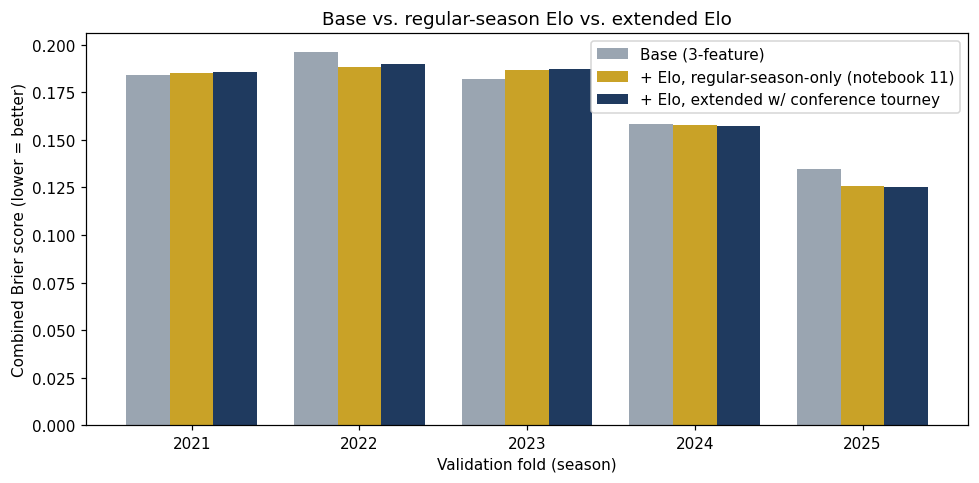

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
plot_df = results_df[results_df["FoldSeason"] != "Average"]
x = np.arange(len(plot_df))
width = 0.26
ax.bar(x - width, plot_df["Combined: base"], width, label="Base (3-feature)", color="#9aa5b1")
ax.bar(x, plot_df["Combined: +Elo (reg-only, nb11)"], width, label="+ Elo, regular-season-only (notebook 11)", color="#c9a227")
ax.bar(x + width, plot_df["Combined: +Elo (extended)"], width, label="+ Elo, extended w/ conference tourney", color="#1f3a5f")
ax.set_xticks(x); ax.set_xticklabels(plot_df["FoldSeason"])
ax.set_ylabel("Combined Brier score (lower = better)")
ax.set_xlabel("Validation fold (season)")
ax.set_title("Base vs. regular-season Elo vs. extended Elo")
ax.legend()
fig.tight_layout()
plt.show()


## 10. Bottom-line comparison

In [10]:
bottom_line = pd.DataFrame([
    {"Model": "Pooled baseline (notebook 03)", "Avg. Brier": 0.1739},
    {"Model": "Gender split, tournament-only (notebook 07)", "Avg. Brier": results_df.loc[results_df['FoldSeason']=='Average', 'Combined: base'].values[0]},
    {"Model": "Gender split + Elo, regular-season-only (notebook 11)", "Avg. Brier": results_df.loc[results_df['FoldSeason']=='Average', 'Combined: +Elo (reg-only, nb11)'].values[0]},
    {"Model": "Gender split + Elo, extended w/ conference tourney (this notebook)", "Avg. Brier": results_df.loc[results_df['FoldSeason']=='Average', 'Combined: +Elo (extended)'].values[0]},
])
print(bottom_line.round(4).to_string(index=False))


                                                             Model  Avg. Brier
                                     Pooled baseline (notebook 03)      0.1739
                       Gender split, tournament-only (notebook 07)      0.1711
             Gender split + Elo, regular-season-only (notebook 11)      0.1687
Gender split + Elo, extended w/ conference tourney (this notebook)      0.1691


## Conclusion

**The extension didn't help — a small step backward, not forward.** The combined score moved
from 0.1687 (notebook 11's regular-season-only Elo) to 0.1691 with conference tournament games
added in, a tiny move in the wrong direction. Three of five folds got slightly worse (2021, 2022,
2023), two improved marginally (2024, 2025) — not a consistent enough pattern to call it a real
gain anywhere.

**Why this likely happened:** the correlation check in Section 6 showed the extended Elo
correlating 0.997 with the original — essentially the same rating. That makes sense: conference
tournament games are only about 4% of the combined game log (13,870 out of roughly 355,000 games
across both genders), so they can't move a team's rating much regardless of how they're weighted.
And because the conference tournament file has no scores, those games all get the same neutral,
average-sized adjustment rather than reflecting their actual margin — a blowout conference-title
game and a one-point nailbiter get treated identically, which likely adds a small amount of noise
without adding real signal.

**Decision, and what it's based on:** keep notebook 11's regular-season-only Elo. The bottom-line
table in Section 10 shows 0.1687 (notebook 11) beating both this notebook's 0.1691 and every
earlier result — it remains the best model in the project.